# 07 - Anomaly Detection with Isolation Forest
**Project:** Air Quality & Pollution Intelligence - Data Mining and Business Intelligence

**Objective:** Find records whose combination of pollutant values is statistically unusual, quantify how many there are, and state clearly what the label does and does not mean.

**How to read this notebook:** every number printed below is produced by the
code in this notebook from `data/raw/Air_quality_data.csv`. Column names are
discovered at runtime through `src/config.py`, so nothing is assumed.


In [1]:
"""Environment bootstrap: make src/ importable and pin the working directory."""
import sys, os, warnings
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 90)
%matplotlib inline
print("project root:", PROJECT_ROOT)

project root: C:\Users\DELL\OneDrive\Desktop\Air Quality


In [2]:
import config as C
import data_utils as U
import preprocessing as P
import feature_engineering as FE
import anomaly_detection as AD
import figures as F
import viz as V
from IPython.display import display, Image

clean, *_ = P.clean(U.load_raw())
feat, _ = FE.build_features(clean)
polls = C.pollutant_columns(feat.columns)
V.style()

## 1. Why Isolation Forest

* It isolates points by random splits, so the cost is linear in the number of
  records - practical at 18,265 rows.
* It does not assume the data is Gaussian (true here: notebook 05 shows uniform-like
  marginals), unlike a Z-score or Mahalanobis approach.
* It uses all pollutant dimensions jointly, so it can flag a record whose
  *combination* of values is unusual even when no single value is extreme.

## 2. The `contamination` parameter

`contamination` is the fraction of records the algorithm is told to treat as
outliers, and it fixes the decision threshold. It is an **assumption**, not a
finding, so the sensitivity to it is reported instead of being buried.

In [3]:
sens = []
for c in (0.01, 0.02, 0.05, 0.10):
    tmp, _, _, _ = AD.detect(feat, polls, contamination=c)
    st = AD.summary(tmp)
    sens.append({"contamination": c, "anomalies": st["Anomalies detected"],
                 "rows_evaluated": st["Rows evaluated"],
                 "observed_pct": st["Anomaly %"]})
display(pd.DataFrame(sens))

,contamination,anomalies,rows_evaluated,observed_pct
0,0.01,183,18265,1.0
1,0.02,366,18265,2.0
2,0.05,914,18265,5.0
3,0.10,1827,18265,10.0


In [4]:
feat, model, used, params = AD.detect(feat, polls)
print("features used :", used)
print("parameters    :", {k: v for k, v in params.items() if k != "features"})
stats_tbl = AD.summary(feat)
for k, v in stats_tbl.items():
    print(f"{k:>24}: {v}")

features used : ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3']
parameters    : {'n_estimators': 300, 'contamination': 0.05, 'random_state': 42, 'rows_evaluated': 18265}
          Rows evaluated: 18265
      Anomalies detected: 914
               Anomaly %: 5.0
Configured contamination: 0.05
                    Note: the detected share follows the contamination parameter; it is an assumed sensitivity, not an independently observed anomaly rate


## 3. Anomaly distribution and score

,records
Anomaly_Label,
Normal,17351
Anomaly,914


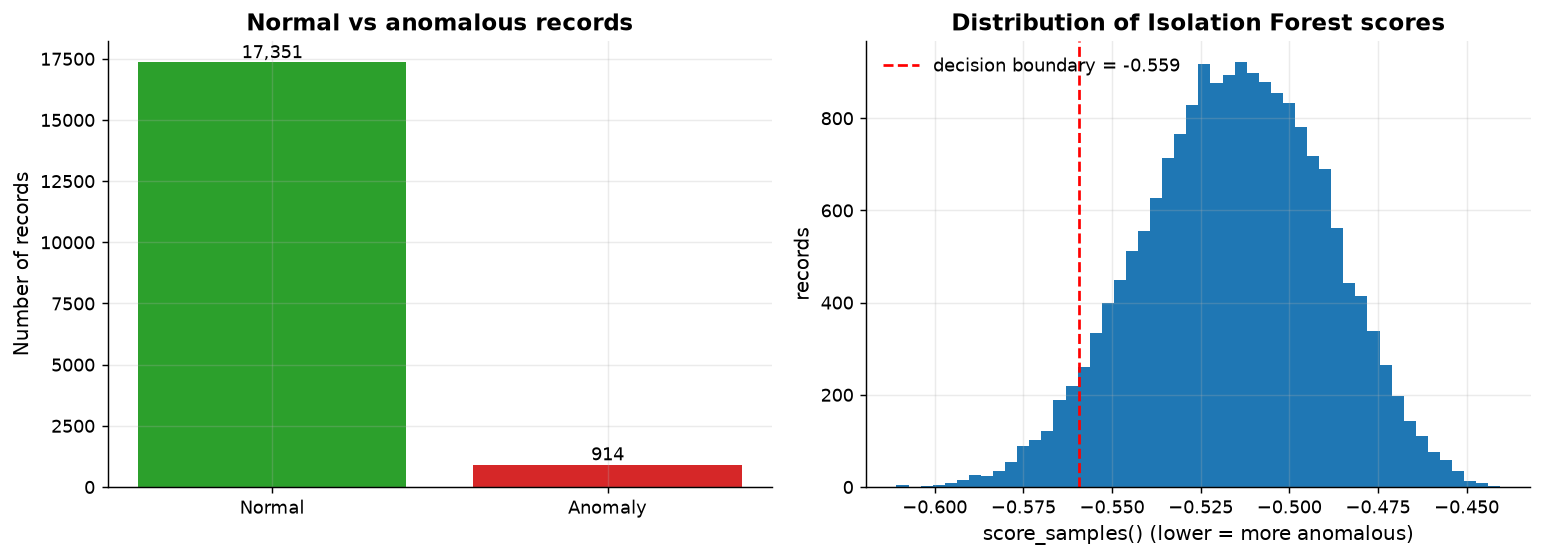

In [5]:
paths = F.anomaly(feat, AD.by_city(feat), AD.by_period(feat, "year"), polls)
display(feat["Anomaly_Label"].value_counts().to_frame("records"))
Image(paths["01_anomaly_distribution"])

## 4. Which cities and which years are flagged?

,City,Observations,Anomalies,Anomaly_Pct
0,Chennai,3653,200.0,5.47
1,Kolkata,3653,189.0,5.17
2,Bangalore,3653,180.0,4.93
3,Mumbai,3653,177.0,4.85
4,Delhi,3653,168.0,4.60


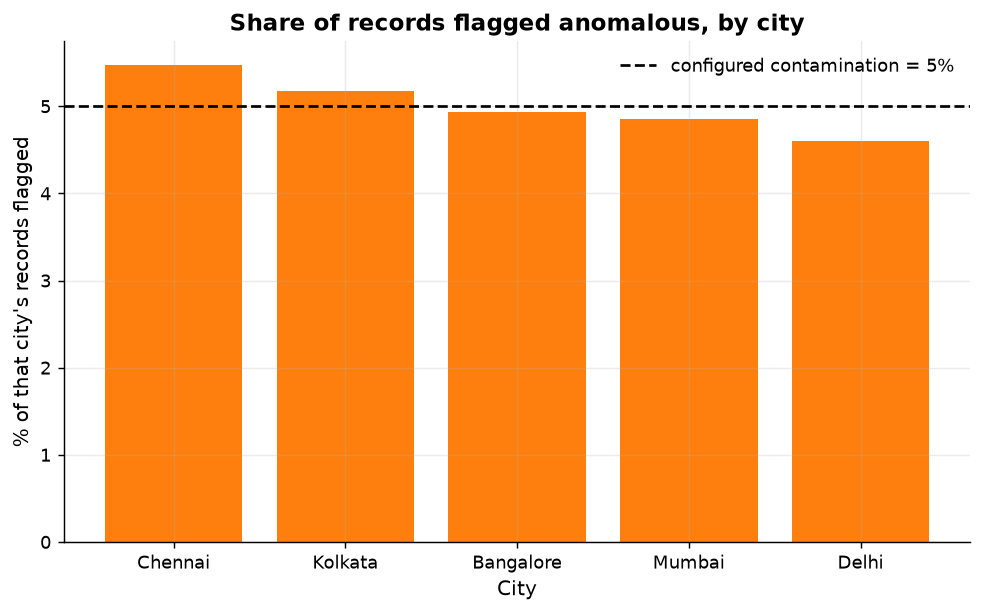

In [6]:
by_city = AD.by_city(feat)
display(by_city)
by_city.to_csv(C.PROCESSED_DIR / "anomaly_by_city.csv", index=False)
Image(paths["02_anomaly_by_city"])

,Period,Observations,Anomalies,Anomaly_Pct
0,2015,1825,87.0,4.77
1,2016,1830,102.0,5.57
2,2017,1825,90.0,4.93
3,2018,1825,83.0,4.55
4,2019,1825,91.0,4.99
5,2020,1830,92.0,5.03
6,2021,1825,108.0,5.92
7,2022,1825,94.0,5.15
8,2023,1825,67.0,3.67
9,2024,1830,100.0,5.46


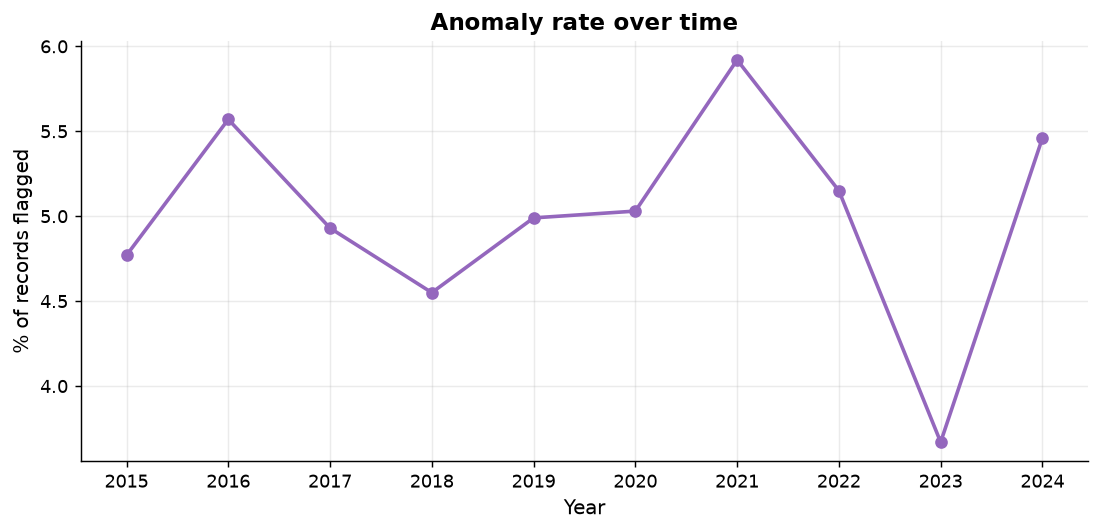

In [7]:
by_year = AD.by_period(feat, "year")
display(by_year)
by_year.to_csv(C.PROCESSED_DIR / "anomaly_by_year.csv", index=False)
Image(paths["03_anomaly_timeline"])

In [8]:
print("is the spread between cities larger than sampling noise would give?")
import statistics_analysis as S
flagged = feat.assign(Is_Anomaly=feat["Anomaly"])
ct = pd.crosstab(flagged[C.CITY_COL], flagged["Anomaly"], values=flagged["AQI"],
                aggfunc="size")
from scipy import stats as sps
chi2, p, dof, _ = sps.chi2_contingency(ct)
print(f"chi-square test of independence between City and Anomaly: chi2={chi2:.3f}, "
      f"df={dof}, p={p:.4g}")
print("expected under a fixed contamination rate: about equal shares in every city")

is the spread between cities larger than sampling noise would give?
chi-square test of independence between City and Anomaly: chi2=3.425, df=4, p=0.4893
expected under a fixed contamination rate: about equal shares in every city


## 5. What makes a record anomalous here?

Comparing the mean pollutant level of flagged and normal records shows which
measurements drive the flag. Note that anomalies are **not** simply the highest
values - the algorithm flags unusual combinations.

,Pollutant,Normal_Mean,Anomaly_Mean,Difference,Pct_Change,Normal_Max,Anomaly_Max
0,PM2.5,250.864,245.549,-5.315,-2.12,499.9,499.8
1,PM10,298.000,326.829,28.830,9.67,600.0,599.9
2,NO,101.219,86.471,-14.748,-14.57,200.0,199.9
3,NO2,75.562,72.649,-2.913,-3.85,150.0,150.0
4,NOx,126.437,116.993,-9.444,-7.47,250.0,250.0
5,NH3,25.012,26.075,1.063,4.25,50.0,50.0
6,CO,4.981,5.412,0.431,8.66,10.0,10.0
7,SO2,49.707,52.275,2.568,5.17,100.0,100.0
8,O3,100.704,94.770,-5.933,-5.89,200.0,199.8


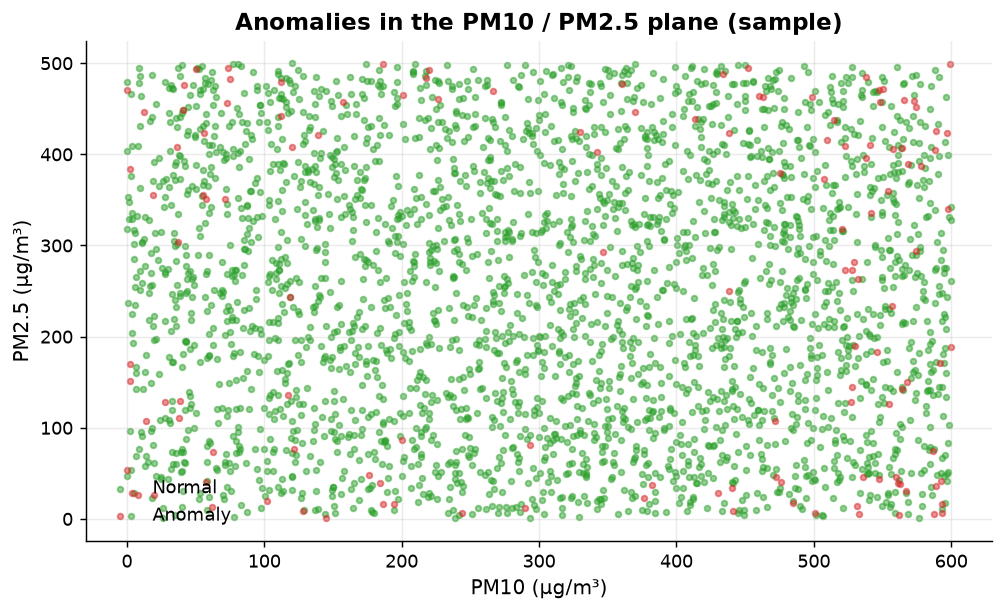

In [9]:
cmp_tbl = AD.pollutant_comparison(feat, polls)
display(cmp_tbl)
cmp_tbl.to_csv(C.PROCESSED_DIR / "anomaly_pollutant_comparison.csv", index=False)
Image(paths["04_anomaly_scatter"])

## 6. The most anomalous records in the file

In [10]:
worst = (feat.nsmallest(15, "Anomaly_Score")
              [[C.CITY_COL, "Date", "Season"] + polls + [C.AQI_COL, C.TARGET_COL,
                                                        "Anomaly_Score"]])
display(worst.reset_index(drop=True))

,City,Date,Season,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI,AQI_Bucket,Anomaly_Score
0,Chennai,2017-12-25,Post-Monsoon,406.0,31.0,0.6,6.7,236.1,49.6,9.21,8.1,33.3,190.1,Moderate,-0.61079
1,Delhi,2020-06-17,Summer,18.2,543.1,142.9,12.7,12.8,0.5,9.73,14.7,184.1,239.3,Poor,-0.61034
2,Chennai,2015-07-07,Monsoon,489.6,249.8,196.4,148.6,2.1,2.5,9.54,80.1,13.6,199.9,Moderate,-0.60997
3,Delhi,2021-03-07,Winter,74.2,9.9,5.7,145.2,111.2,37.9,9.93,98.7,165.5,199.1,Moderate,-0.60958
4,Kolkata,2022-02-16,Winter,459.4,565.3,23.7,149.0,108.0,0.2,9.99,18.7,197.4,273.1,Poor,-0.60823
5,Mumbai,2018-06-05,Summer,474.4,575.5,3.4,148.1,79.5,49.0,3.56,15.6,2.3,168.1,Moderate,-0.60391
6,Chennai,2016-02-08,Winter,483.5,47.8,189.8,50.6,247.4,1.6,0.65,97.2,91.2,106.4,Moderate,-0.60101
7,Bangalore,2017-03-27,Winter,484.7,8.4,111.4,149.4,25.3,26.1,9.92,10.9,190.2,254.8,Poor,-0.59965
8,Mumbai,2024-01-01,Winter,94.7,554.0,195.2,3.3,243.2,3.1,7.38,97.1,38.9,213.6,Poor,-0.59851
9,Bangalore,2018-03-14,Winter,154.1,36.7,18.4,3.2,20.7,44.4,0.23,6.9,12.4,326.4,Very Poor,-0.59833


## 7. Interpretation limits

An anomaly label means "this record is far from the bulk of the data in the
chosen feature space". It does **not** identify a cause. Naming a cause (fireworks,
stubble burning, a dust storm, a sensor fault) would need activity or maintenance
data that this dataset does not contain, so no cause is asserted.

In [11]:
keep = [c for c in [C.CITY_COL, "Date", "Year", "Month", "Season"] + polls +
          [C.AQI_COL, C.TARGET_COL, "Anomaly", "Anomaly_Label", "Anomaly_Score",
           "Cluster"] if c in feat.columns]
feat[keep].to_csv(C.ANOMALY_RESULTS_CSV, index=False)
print("saved:", C.ANOMALY_RESULTS_CSV.name, "rows:", len(feat))

saved: anomaly_results.csv rows: 18265


## Verification checklist

- [x] Feature set restricted to measured concentrations
- [x] Contamination sensitivity reported
- [x] Anomaly share compared against the configured rate
- [x] City/year breakdowns tested for non-randomness
- [x] No causal explanation claimed

**Common errors**

| Error | Meaning | Fix |
|---|---|---|
| `ValueError: could not convert string to float` | a categorical column entered the feature list | pass only `C.pollutant_columns(...)` |
| All scores identical | a constant column dominates | drop zero-variance columns |

**Next:** `08_classification.ipynb`.